In [20]:
from utils import * 
import json
import itertools 
import networkx as nx
import subprocess
import seaborn as sns 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import math 

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0) # All genes passing the filters in analysis-1.ipynb
print('Number of genomes:', genes_df.genome_id.nunique())
print('Number of genes:', len(genes_df))
# copy_structures(genes_df.index, source_dir='../data/genes/colabfold/', output_dir='../data/genes/colabfold/genes')

reverse_complement_genome_ids = ['bz_0', 'bz_1', 'bz_4', 'bz_5', 'bz_7', 'bz_8','bz_12']

# for row in genes_df.itertuples():
#     if (row.genome_id in reverse_complement_genome_ids):
#         genes_df.loc[row.Index, 'start'] = row.genome_size - (row.stop + 1)
#         genes_df.loc[row.Index, 'stop'] = row.genome_size - (row.start - 1) 
#         genes_df.loc[row.Index, 'strand'] = '+' if (row.strand == '-') else '-'

Number of genomes: 12
Number of genes: 1633


In [22]:
MMSEQS_QUERY_PATH = '../data/genes/genes.faa'
MMSEQS_TARGET_PATH = MMSEQS_QUERY_PATH
MMSEQS_OUTPUT_PATH = '../data/genes/mmseqs/genes-genes.tsv'
MMSEQS_TMP_DIR = '../data/tmp/'
MMSEQS_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qcov,tcov,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch"'

MMSEQS_PARAMS = dict()
MMSEQS_PARAMS['-s'] = 9.5 # Maximum sensitiviy search. 
MMSEQS_PARAMS['-a'] = '' # Add a backtrace string. 
MMSEQS_PARAMS['--format-output'] = MMSEQS_FIELDS 

cmd = f'mmseqs easy-search {MMSEQS_QUERY_PATH} {MMSEQS_TARGET_PATH} {MMSEQS_OUTPUT_PATH} {MMSEQS_TMP_DIR}'
for param, value in MMSEQS_PARAMS.items():
    cmd += f' {param} {value}'
print(cmd)
# subprocess.run(cmd, shell=True, check=True)

mmseqs_df = pd.read_csv(MMSEQS_OUTPUT_PATH, names=MMSEQS_FIELDS.replace('"','').split(','), sep='\t')
mmseqs_df['pair_id'] = mmseqs_df.apply(lambda row : '-'.join(sorted([getattr(row, 'query'), getattr(row, 'target')])), axis=1)
mmseqs_df = mmseqs_df.sort_values('bits', ascending=False) # Sort by bits, with highest bitscores first. 

filters = dict()
filters['self_alignments'] = mmseqs_df['query'] == mmseqs_df['target']
filters['duplicate_pairs'] = mmseqs_df.pair_id.duplicated(keep='first') # Sorted by bits, so this will keep the best alignment.

mmseqs_df = apply_filters(filters, mmseqs_df)


mmseqs easy-search ../data/genes/genes.faa ../data/genes/genes.faa ../data/genes/mmseqs/genes-genes.tsv ../data/tmp/ -s 9.5 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qcov,tcov,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch"
apply_filters: 1592 entries removed by self_alignments.
apply_filters: 773 entries removed by duplicate_pairs.


In [23]:
# print('Number of Foldseek alignments:', len(foldseek_df))
# print('Number of MMseqs alignments:', len(mmseqs_df))

# palette = {'MMseqs':'gray', 'Foldseek':'steelblue'}
# fig, ax = plt.subplots(figsize=(4, 3))

# figure_df = mmseqs_df[['bits', 'evalue']].assign(source='MMseqs')
# figure_df = pd.concat([figure_df, foldseek_df[['bits', 'evalue']].assign(source='Foldseek')])

# sns.kdeplot(figure_df, x='bits', hue='source', common_norm=False, palette=palette)

# for source, df in figure_df.groupby('source'):
#     mean = df['bits'].mean()
#     ax.axvline(df['bits'].mean(), ls='--', color=palette.get(source))
#     ax.text(mean, ax.get_ylim()[-1], str(int(mean)), ha='center')


# ax.get_legend().set_title('')
# ax.set_xlim(xmax=500, xmin=0)

# plt.show()


In [24]:
graph = nx.Graph()
filter_ = (mmseqs_df.qcov > 0.75) & (mmseqs_df.tcov > 0.75)
filter_ = filter_ & (mmseqs_df.bits > 40)

edges = [(row.query, row.target) for row in mmseqs_df[filter_].itertuples()]
# edges += [(row.query, row.target) for row in foldseek_df[filter_].itertuples()]
graph.add_edges_from(edges)
graph.add_nodes_from(genes_df.index.values)

clusters = list(nx.connected_components(graph))
clusters = sorted(clusters, key=len)[::-1]
clusters = {i:cluster for i, cluster in enumerate(clusters)}

cluster_df = pd.DataFrame.from_dict({gene_id:i for i, cluster in clusters.items() for gene_id in cluster}, orient='index', columns=['cluster_id'])
cluster_df = cluster_df.reset_index(names='gene_id')
cluster_df['genome_id'] = cluster_df.gene_id.apply(get_genome_id)
cluster_df = cluster_df[cluster_df.genome_id != 'bz_12'].copy()
cluster_df['cluster_num_genomes'] = cluster_df.groupby('cluster_id').genome_id.transform('nunique')
cluster_df['cluster_size'] = cluster_df.groupby('cluster_id').transform('size')

genes_df = genes_df.drop(columns=cluster_df.columns, errors='ignore')
genes_df = genes_df.merge(cluster_df.set_index('gene_id'), left_index=True, right_index=True, how='inner')
genes_df['length'] = genes_df.seq.apply(len)

with open('../data/genes/clusters.json', 'w') as f:
    json.dump(genes_df.cluster_id.to_dict(), f)



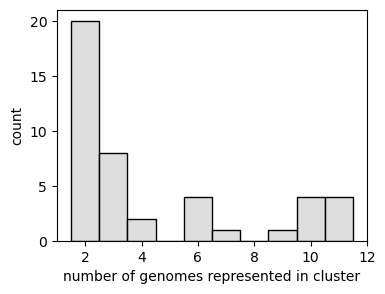

Number of clusters in 9 genomes: 1
Number of clusters in 10 genomes: 4
Number of clusters in 11 genomes: 4

Maximum number of cluster_14 genes in a genome: 1
Maximum number of cluster_15 genes in a genome: 1
Maximum number of cluster_17 genes in a genome: 1
Maximum number of cluster_18 genes in a genome: 1
Maximum number of cluster_19 genes in a genome: 1
Maximum number of cluster_20 genes in a genome: 1
Maximum number of cluster_21 genes in a genome: 1
Maximum number of cluster_23 genes in a genome: 1
Maximum number of cluster_24 genes in a genome: 1
Maximum number of cluster_25 genes in a genome: 1
Maximum number of cluster_27 genes in a genome: 1
Maximum number of cluster_28 genes in a genome: 1
Maximum number of cluster_29 genes in a genome: 1
Maximum number of cluster_31 genes in a genome: 1
Maximum number of cluster_33 genes in a genome: 1
Maximum number of cluster_34 genes in a genome: 1
Maximum number of cluster_35 genes in a genome: 1
Maximum number of cluster_39 genes in a ge

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = cluster_df.drop_duplicates('cluster_id').copy()
figure_df = figure_df[figure_df.cluster_num_genomes > 1].copy()

# sns.histplot(figure_df, x='cluster_size', discrete=True, alpha=0.5, color='gray')
sns.histplot(figure_df, x='cluster_num_genomes', discrete=True, color='lightgray')
ax.set_ylabel('count')
ax.set_xlabel('number of genomes represented in cluster')
plt.show()

print('Number of clusters in 9 genomes:', (figure_df.cluster_size == 9).sum())
print('Number of clusters in 10 genomes:', (figure_df.cluster_size == 10).sum())
print('Number of clusters in 11 genomes:', (figure_df.cluster_size == 11).sum(), end='\n\n')

level_1_conserved_cluster_ids = genes_df[genes_df.cluster_num_genomes > 8].cluster_id.unique().tolist()
level_2_conserved_cluster_ids = genes_df[(genes_df.cluster_num_genomes < 9) & (genes_df.cluster_num_genomes > 5)].cluster_id.unique().tolist()
level_3_conserved_cluster_ids = genes_df[(genes_df.cluster_num_genomes < 6) & (genes_df.cluster_num_genomes > 1)].cluster_id.unique().tolist()
conserved_cluster_ids = level_1_conserved_cluster_ids + level_2_conserved_cluster_ids + level_3_conserved_cluster_ids

genes_df['conserved'] = genes_df.cluster_id.isin(conserved_cluster_ids)

# level_1_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_1_conserved_cluster_ids} 
# level_2_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_2_conserved_cluster_ids} 
# level_3_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_3_conserved_cluster_ids} 

for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_3_conserved_cluster_ids)].groupby('cluster_id'):
    print(f'Maximum number of cluster_{cluster_id} genes in a genome:', df.genome_id.value_counts().max())

In [28]:
# print('Highly-conserved cluster IDs:', level_1_conserved_cluster_ids.tolist())
# print('Moderately-conserved cluster IDs:', level_2_conserved_cluster_ids.tolist())
# print('Weakly-conserved cluster IDs:', level_3_conserved_cluster_ids.tolist())

print('level_1_conserved_cluster_ids =', level_1_conserved_cluster_ids)
print('level_2_conserved_cluster_ids =', level_2_conserved_cluster_ids)
print('level_3_conserved_cluster_ids =', level_3_conserved_cluster_ids)

level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]


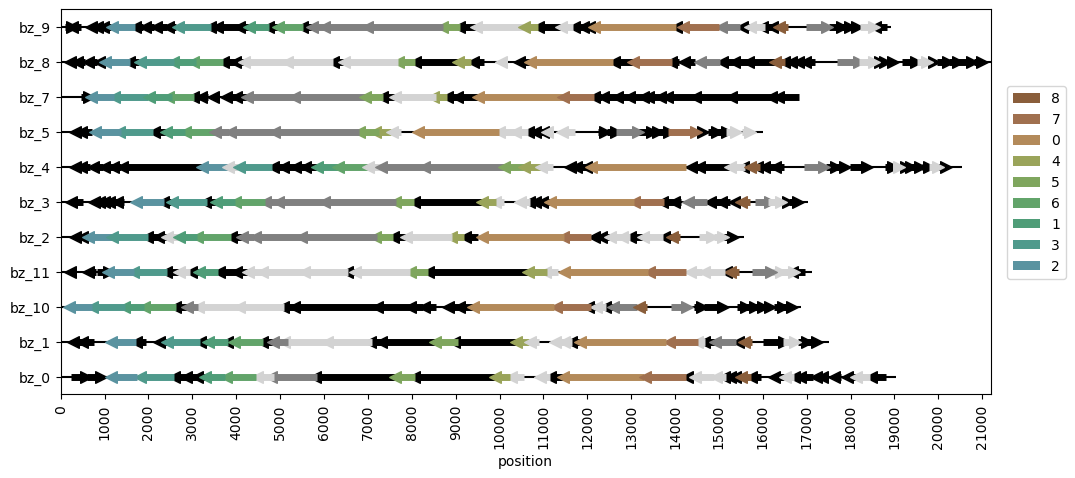

In [29]:


fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', '#4F9A8C', '#5A93A0', '#6A89B0', '#7A7FB8']
palette = dict(zip(level_1_conserved_cluster_ids, colors))
palette.update({cluster_id:'gray' for cluster_id in level_2_conserved_cluster_ids})
palette.update({cluster_id:'lightgray' for cluster_id in level_3_conserved_cluster_ids})
palette.update({cluster_id:'black' for cluster_id in genes_df.cluster_id.unique() if (cluster_id not in palette)})

figure_df = genes_df.copy()
figure_df['gene_id'] = figure_df.index
# figure_df = genes_df[genes_df.cluster_id.isin(palette)].copy()
figure_df = figure_df.reset_index(drop=True)
figure_df = figure_df[~figure_df.prodigal_gene_id.isnull()].copy()


def plot_orfs(figure_df:pd.DataFrame, palette=dict(), color_by:str='cluster_id'):

    figure_df = figure_df.sort_values('genome_id')
    figure_df['genome_num'] = pd.factorize(figure_df.genome_id)[0]

    for row in figure_df.drop_duplicates('genome_id').itertuples():
        ax.hlines(y=row.genome_num, color='black', xmin=0, xmax=row.genome_size, zorder=-1)

    for row in figure_df.itertuples():
        color = palette.get(getattr(row, color_by), 'black')
        z_order = -1 if (color == 'black') else 1
        ax.hlines(y=[row.genome_num], xmin=row.start, xmax=row.stop, linewidth=5, color=color, zorder=z_order)
        if row.strand == '+':
            ax.scatter([row.stop], [row.genome_num], s=70, marker='>', color=color, zorder=z_order)
        elif row.strand == '-':
            ax.scatter([row.start], [row.genome_num], s=70, marker='<', color=color, zorder=z_order)

    # labels = sorted(list(palette.keys()))
    labels = level_1_conserved_cluster_ids
    handles = [Patch(facecolor=palette[cluster_id], label=cluster_id) for cluster_id in labels]
    ax.legend(handles, labels, bbox_to_anchor=(1.01, 0.55), loc='center left')

    ax.set_xlim(xmin=0, xmax=figure_df.genome_size.max())
    ax.set_yticks(figure_df.genome_num.unique(), labels=figure_df.genome_id.unique())
    ax.set_xticks(np.arange(0, 22000, 1000), labels=np.arange(0, 22000, 1000), rotation=90)
    ax.set_xlabel('position')
    plt.show()


plot_orfs(figure_df, palette=palette)

In [30]:
for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):
    info = f'cluster_{cluster_id}'
    info += f'\tlengths: {df.length.min()} - {df.length.max()}'
    info += f'\tany/all predicted by Prodigal: {np.any(~df.prodigal_gene_id.isnull())}/{np.all(~df.prodigal_gene_id.isnull())}'
    print(info)
# mmseqs_df[mmseqs_df['query'].isin(cluster_0_gene_ids) & mmseqs_df['target'].isin(cluster_0_gene_ids)]

cluster_0	lengths: 610 - 715	any/all predicted by Prodigal: True/True
cluster_1	lengths: 138 - 153	any/all predicted by Prodigal: True/True
cluster_2	lengths: 173 - 196	any/all predicted by Prodigal: True/True
cluster_3	lengths: 244 - 266	any/all predicted by Prodigal: True/True
cluster_4	lengths: 90 - 125	any/all predicted by Prodigal: True/True
cluster_5	lengths: 126 - 149	any/all predicted by Prodigal: True/True
cluster_6	lengths: 177 - 253	any/all predicted by Prodigal: True/True
cluster_7	lengths: 207 - 311	any/all predicted by Prodigal: True/True
cluster_8	lengths: 53 - 69	any/all predicted by Prodigal: True/True


In [ ]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']

annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
annot_df['cluster_id'] = annot_df.gene_id.map(cluster_df.set_index('gene_id').cluster_id)

annot_df[annot_df.cluster_id == 7]
genes_df[genes_df.cluster_id == 7]


,nt_seq,description,seq,frame,gene_number,start,stop,strand,partial,has_start_codon,...,prodigal_start_idx,genome_size,seq_untrimmed,nt_seq_untrimmed,num_residues_trimmed,cluster_id,genome_id,cluster_num_genomes,cluster_size,length
gene_id,,,,,,,,,,,,,,,,,,,,,
orfm.bz_0.1_82,ATGGTATCTTCAAGTTATCAATCAAAACAACATAAAACTTCTTATC...,NaN,MVSSSYQSKQHKTSYHPVKKPAKITGTSYFSQRKLRAGISSYQPQR...,1,82,4792,5732,+,False,True,...,-1.0,19040,MVSSSYQSKQHKTSYHPVKKPAKITGTSYFSQRKLRAGISSYQPQR...,ATGGTATCTTCAAGTTATCAATCAAAACAACATAAAACTTCTTATC...,0,7,bz_0,10,10,311
orfm.bz_1.1_43,GTGCACATGAAAAAAATAAAAATAAATATTATCTCTAAAACAGGTT...,NaN,VHMKKIKINIISKTGSIQKREIKKDNLIFYERKGKYYIKKEKIKIS...,2,43,2978,3648,+,False,True,...,1.0,17509,FSKVHMKKIKINIISKTGSIQKREIKKDNLIFYERKGKYYIKKEKI...,TTTTCAAAGGTGCACATGAAAAAAATAAAAATAAATATTATCTCTA...,3,7,bz_1,10,10,218
orfm.bz_2.1_117,ATGGCACGAAAAGTATATGATTTTCCTTTATTTAAATTGGAAGAAT...,NaN,MARKVYDFPLFKLEELAKEKNLKLYKSAFKEESQYKAYIEFKKRQK...,5,117,11449,12079,-,False,True,...,-1.0,15579,TMARKVYDFPLFKLEELAKEKNLKLYKSAFKEESQYKAYIEFKKRQ...,ACAATGGCACGAAAAGTATATGATTTTCCTTTATTTAAATTGGAAG...,1,7,bz_2,10,10,208
orfm.bz_3.1_142,ATGAAAAAAATTTTAATTAAAATATTACAAAAAAATAATATAATTT...,NaN,MKKILIKILQKNNIISSRNIQKSNKKFYIYDRKIKAYRKKSKIEIS...,4,142,13059,13758,-,False,True,...,-1.0,17033,IYRCRLYIKKFRSKMKKILIKILQKNNIISSRNIQKSNKKFYIYDR...,ATTTATAGATGTAGATTATATATTAAAAAATTTAGGAGTAAAATGA...,14,7,bz_3,10,10,218
orfm.bz_5.1_26,ATGAGCAAATCTAAATATATTCAAATTTCAATTATTAACAAGAAAG...,NaN,MSKSKYIQISIINKKGKKTLVTILRKNKKNYIRDSELKGLIKIPVK...,4,26,1531,2177,-,False,True,...,-1.0,16014,IWEVFTMSKSKYIQISIINKKGKKTLVTILRKNKKNYIRDSELKGL...,ATTTGGGAAGTTTTCACAATGAGCAAATCTAAATATATTCAAATTT...,6,7,bz_5,10,10,207
orfm.bz_7.1_68,ATGACAAAAGATAAATACATAACAATAAAACTTATTACAAAAAATA...,NaN,MTKDKYITIKLITKNNKVQTRKVKKAILKQYVKTKEGYYRKKIPVI...,1,68,4672,5366,+,False,True,...,-1.0,16817,IMTKDKYITIKLITKNNKVQTRKVKKAILKQYVKTKEGYYRKKIPV...,ATTATGACAAAAGATAAATACATAACAATAAAACTTATTACAAAAA...,1,7,bz_7,10,10,228
orfm.bz_8.1_106,TTGGTAATAAAAGCAGATGATATAGAACGTATAAAACAATTACGTA...,NaN,LVIKADDIERIKQLRKAGKTGSQISKEIHKRKSETLRIIRIIESKK...,1,106,7270,8162,+,False,True,...,-1.0,21195,INGVCDKLVIKADDIERIKQLRKAGKTGSQISKEIHKRKSETLRII...,ATTAATGGAGTATGTGATAAATTGGTAATAAAAGCAGATGATATAG...,7,7,bz_8,10,10,288
orfm.bz_9.1_152,ATGGTAAACATAGAAAAAATAAAAGAATTAAGAAGTAAGGGTTTTT...,NaN,MVNIEKIKELRSKGFSGSKIAKELHLRKQVTLQIIREIEHRKKPKS...,5,152,14173,14992,-,False,True,...,-1.0,18925,MVNIEKIKELRSKGFSGSKIAKELHLRKQVTLQIIREIEHRKKPKS...,ATGGTAAACATAGAAAAAATAAAAGAATTAAGAAGTAAGGGTTTTT...,0,7,bz_9,10,10,272
orfm.bz_10.1_110,ATGATTACAAATGAAGATAGAAAAAATATAAAGCGATATATTGAAG...,NaN,MITNEDRKNIKRYIEEEKTGKEIAVLIHKRYQTVLDEIRNIKNVPK...,6,110,11285,12074,-,False,True,...,-1.0,16872,LFSIRAYKRKRQYRIIMITNEDRKNIKRYIEEEKTGKEIAVLIHKR...,TTATTTTCAATCAGAGCCTATAAAAGAAAAAGACAGTATAGGATTA...,16,7,bz_10,10,10,246


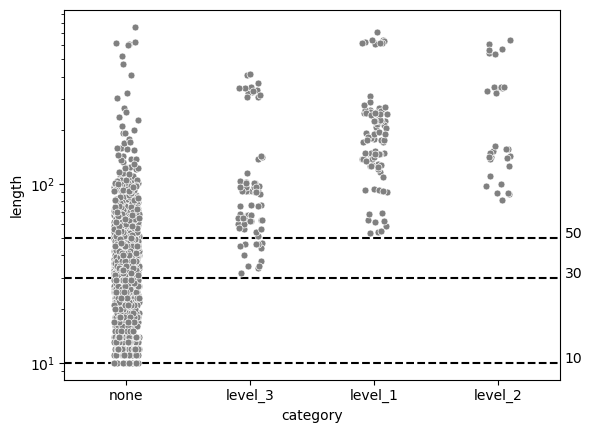

In [ ]:
fig, ax = plt.subplots()

figure_df = genes_df.copy()

categories = dict()
categories['level_1'] = figure_df.index.isin([gene_id for gene_ids in level_1_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories['level_2'] = figure_df.index.isin([gene_id for gene_ids in level_2_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories['level_3'] = figure_df.index.isin([gene_id for gene_ids in level_3_conserved_cluster_gene_ids.values() for gene_id in gene_ids])

categories, conditions = list(zip(*categories.items()))
figure_df['category'] = np.select(conditions, categories, default='none')

sns.stripplot(figure_df, x='category', y='length', color='gray', edgecolor='white', linewidth=0.5)

for y in [10, 30, 50]:
    ax.axhline(y, ls='--', color='black')
    ax.text(ax.get_xlim()[-1] * 1.01, y, str(y))
ax.set_yscale('log')

In [ ]:
# What is the minimum bit score for alignments between members of the same cluster?

for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):
    gene_ids = df.index.values 
    mmseqs_df_ = mmseqs_df[mmseqs_df['query'].isin(gene_ids) & mmseqs_df['target'].isin(gene_ids)].copy() # Self-alignments and duplicate alignments have already been removed. 
    n_alignments = len(mmseqs_df_)
    n_possible_alignments = math.comb(len(gene_ids), 2)

    print(f'Minimum percent identity for cluster {int(cluster_id)}:', mmseqs_df_.pident.min(), f'with {n_alignments} out of {n_possible_alignments} alignments made.')
    # print(f'Minimum bit score for cluster {cluster_id}:', mmseqs_df_.bits.min(), f'with {n_alignments} out of {n_possible_alignments} alignments made.')
    # print(f'Maximum E-value for cluster {cluster_id}:', mmseqs_df_.evalue.max(), f'with {n_alignments} out of {n_possible_alignments} alignments made.') # E-value is kind of useless because it is database-dependent. 

Minimum percent identity for cluster 0: 23.4 with 55 out of 55 alignments made.
Minimum percent identity for cluster 1: 25.3 with 53 out of 55 alignments made.
Minimum percent identity for cluster 2: 23.7 with 55 out of 55 alignments made.
Minimum percent identity for cluster 3: 34.2 with 55 out of 55 alignments made.
Minimum percent identity for cluster 4: 25.2 with 37 out of 45 alignments made.
Minimum percent identity for cluster 5: 26.9 with 45 out of 45 alignments made.
Minimum percent identity for cluster 6: 21.2 with 42 out of 45 alignments made.
Minimum percent identity for cluster 7: 24.0 with 44 out of 45 alignments made.
Minimum percent identity for cluster 8: 32.0 with 34 out of 36 alignments made.


In [36]:
genes_df.loc['orfm.bz_7.1_95']

nt_seq                              ATGAAAATAGCTATAATAGGTTCACATGGAACAGGCAAAACAACAA...
description                                                                       NaN
seq                                 MKIAIIGSHGTGKTTICNEFIKKHPEYFLIPEIARVFGIEKIEKCI...
frame                                                                               1
gene_number                                                                        95
start                                                                            9037
stop                                                                             9519
strand                                                                              -
partial                                                                         False
has_start_codon                                                                  True
has_stop_codon                                                                   True
stop_codon                                            

In [ ]:
genes_df = genes_df[(~genes_df.prodigal_gene_id.isnull()) | genes_df.conserved].copy()

INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
annot_df = annot_df[annot_df.gene_id.isin(genes_df.index)].copy()

filters = dict()
filters['consensus_disorder_prediction'] = annot_df.signature_accession == 'mobidb-lite'
filters['coil'] = annot_df.signature_accession == 'Coil'

annot_df = apply_filters(filters, annot_df)
annot_df['conserved'] = annot_df.gene_id.map(genes_df.conserved)

annot_df.conserved.value_counts()
annot_df[~annot_df.conserved]



# orfm.bz_0.1_132 Carobxypeptidase, cleaves the C-terminal portion of proteins. 

# orfm.bz_1.1_91 NodB homology domain; this is some kind of deacetylase. 

# orfm.bz_8.1_75 Ribonuclease. 
# orfm.bz_8.1_29 GNAT family acetyltransferase
# orfm.bz_8.1_110 Phosphohydrolase, MazG-like. https://pmc.ncbi.nlm.nih.gov/articles/PMC3855555/

# orfm.bz_7.1_37 Pentapeptide repeats. 
# orfm.bz_7.1_18 Pentapeptide repeats. 
# orfm.bz_7.1_56 Is possibly related to lipid biogenesis, but otherwise uncharacterized. https://www.ebi.ac.uk/interpro/entry/pfam/PF18902/
# orfm.bz_7.1_95 Another ATPase. 
# orfm.bz_7.1_5 This family of proteins includes various functions such as cell adhesion, biofilm formation, and virulence in pathogens. Some members act as chaperones facilitating protein secretion, while others are involved in invasive growth and cell-cell adhesion.

# orfm.bz_9.1_111 Fibronectin, involved in cell adhesion. 

# orfm.bz_11.1_108 Pectin lyase, helps degrade cell walls https://www.ebi.ac.uk/interpro/entry/InterPro/IPR012334/

apply_filters: 16 entries removed by consensus_disorder_prediction.
apply_filters: 22 entries removed by coil.


,gene_id,checksum,length,analysis,signature_accession,signature_description,annotation_start,annotation_stop,annotation_e_value,annotation_status,date,interpro_accession,interpro_description,go_terms,pathways,conserved
25,orfm.bz_7.1_56,ee79e7680a69558660e08f021857b41a,115,Pfam,PF18902,Domain of unknown function (DUF5658),15,99,6.3E-7,T,16-06-2026,IPR043717,Domain of unknown function DUF5658,-,-,False
38,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,ProSiteProfiles,PS51677,NodB homology domain profile.,192,473,14.8961,T,16-06-2026,IPR002509,NodB homology domain,-,-,False
39,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,Pfam,PF01522,Polysaccharide deacetylase,193,302,1.6E-13,T,16-06-2026,IPR002509,NodB homology domain,-,-,False
40,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,SUPERFAMILY,SSF88713,Glycoside hydrolase/deacetylase,193,416,2.78E-20,T,16-06-2026,IPR011330,"Glycoside hydrolase/deacetylase, beta/alpha-ba...",-,-,False
41,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,PANTHER,PTHR34216,-,193,328,1.1E-21,T,16-06-2026,IPR051398,Polysaccharide Deacetylase,-,-,False
42,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,165,349,7.1E-25,T,16-06-2026,-,-,-,-,False
76,orfm.bz_8.1_110,fca83d1db83b4049f85bf892393c9d94,139,Gene3D,G3DSA:1.10.287.1080,-,20,135,9.0E-15,T,16-06-2026,-,-,-,-,False
77,orfm.bz_8.1_110,fca83d1db83b4049f85bf892393c9d94,139,Pfam,PF03819,MazG nucleotide pyrophosphohydrolase domain,77,132,0.14,T,16-06-2026,IPR004518,NTP pyrophosphohydrolase MazG-like domain,-,-,False
78,orfm.bz_8.1_110,fca83d1db83b4049f85bf892393c9d94,139,SUPERFAMILY,SSF101386,all-alpha NTP pyrophosphatases,67,132,1.64E-12,T,16-06-2026,-,-,-,-,False
80,orfm.bz_7.1_5,784a8d1e900c378dc033a90c6b2a5d53,157,PANTHER,PTHR10068,BONE MARROW PROTEOGLYCAN,24,128,8.5E-14,T,16-06-2026,-,-,-,-,False


In [ ]:
# FOLDSEEK_QUERY_PATH = '../data/genes/colabfold/genes/'
# FOLDSEEK_TARGET_PATH = FOLDSEEK_QUERY_PATH
# FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/genes-genes.tsv'
# FOLDSEEK_TMP_DIR = '../data/tmp/'
# FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'

# FOLDSEEK_PARAMS = dict()
# FOLDSEEK_PARAMS['-s'] = 9.5 # Maximum sensitiviy search. 
# FOLDSEEK_PARAMS['--alignment-type'] = 1 # Make sure to actually align the structures.
# FOLDSEEK_PARAMS['-a'] = '' # Add a backtrace string. 
# FOLDSEEK_PARAMS['--format-output'] = FOLDSEEK_FIELDS 

# cmd = f'foldseek easy-search {FOLDSEEK_QUERY_PATH} {FOLDSEEK_TARGET_PATH} {FOLDSEEK_OUTPUT_PATH} {FOLDSEEK_TMP_DIR}'
# for param, value in FOLDSEEK_PARAMS.items():
#     cmd += f' {param} {value}'
# print(cmd)
# # subprocess.run(cmd, shell=True, check=True)

# foldseek_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, names=FOLDSEEK_FIELDS.replace('"','').split(','), sep='\t')
# foldseek_df['pair_id'] = foldseek_df.apply(lambda row : '-'.join(sorted([getattr(row, 'query'), getattr(row, 'target')])), axis=1)
# foldseek_df = foldseek_df.sort_values('bits', ascending=False) # Sort by bits, with highest bitscores first. 

# filters = dict()
# filters['self_alignments'] = foldseek_df['query'] == foldseek_df['target']
# filters['duplicate_pairs'] = foldseek_df.pair_id.duplicated(keep='first') # Sorted by bits, so this will keep the best alignment.

# foldseek_df = apply_filters(filters, foldseek_df)

